In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
CANDIDATES = [ROOT] + list(ROOT.parents)
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'src').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 01 EDA
Tong quan du lieu crypto va thong ke co ban.

In [2]:
import sys
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().resolve()
CANDIDATES = [ROOT] + list(ROOT.parents)
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'src').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.data.loader import load_all_coins
df = load_all_coins(str(PROJECT_ROOT / 'data' / 'raw'))
df.head()

,sno,name,symbol,date,high,low,open,close,volume,marketcap,coin
0,1,Aave,AAVE,2020-10-05 23:59:59,55.112358,49.787900,52.675035,53.219243,0.000000e+00,8.912813e+07,Aave
1,2,Aave,AAVE,2020-10-06 23:59:59,53.402270,40.734578,53.291969,42.401599,5.830915e+05,7.101144e+07,Aave
2,3,Aave,AAVE,2020-10-07 23:59:59,42.408314,35.970690,42.399947,40.083976,6.828342e+05,6.713004e+07,Aave
3,4,Aave,AAVE,2020-10-08 23:59:59,44.902511,36.696057,39.885262,43.764463,1.658817e+06,2.202651e+08,Aave
4,5,Aave,AAVE,2020-10-09 23:59:59,47.569533,43.291776,43.764463,46.817744,8.155377e+05,2.356322e+08,Aave


In [3]:
df.groupby('coin').size().sort_values(ascending=False).head(15)

coin
Bitcoin        2991
Litecoin       2991
XRP            2893
Dogecoin       2760
Monero         2602
Stellar        2527
Tether         2318
NEM            2288
Ethereum       2160
Iota           1484
EOS            1466
BinanceCoin    1442
Tron           1392
ChainLink      1385
Cardano        1374
dtype: int64

## Thiet lap hien thi
Canh mau duoc thong nhat theo palette #4F6367, #EEF5DB, #FE5F55.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"stormcloud": "#4F6367", "beige": "#EEF5DB", "sunset": "#FE5F55"}
sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = palette["beige"]
plt.rcParams["axes.facecolor"] = palette["beige"]
plt.rcParams["axes.edgecolor"] = palette["stormcloud"]
plt.rcParams["axes.labelcolor"] = palette["stormcloud"]
plt.rcParams["xtick.color"] = palette["stormcloud"]
plt.rcParams["ytick.color"] = palette["stormcloud"]
plt.rcParams["text.color"] = palette["stormcloud"]

In [5]:
summary_overview = pd.DataFrame({
    "n_rows": [len(df)],
    "n_coins": [df["coin"].nunique()],
    "start_date": [df["date"].min()],
    "end_date": [df["date"].max()]
})
summary_overview

,n_rows,n_coins,start_date,end_date
0,37082,23,2013-04-29 23:59:59,2021-07-06 23:59:59


In [6]:
coin_stats = df.groupby("coin").agg(
    first_date=("date", "min"),
    last_date=("date", "max"),
    rows=("date", "size"),
    avg_close=("close", "mean"),
    median_volume=("volume", "median")
).sort_values("rows", ascending=False)
coin_stats.head(20)

,first_date,last_date,rows,avg_close,median_volume
coin,,,,,
Bitcoin,2013-04-29 23:59:59,2021-07-06 23:59:59,2991,6711.290443,9.460360e+08
Litecoin,2013-04-29 23:59:59,2021-07-06 23:59:59,2991,49.279008,1.158300e+08
XRP,2013-08-05 23:59:59,2021-07-06 23:59:59,2893,0.234790,1.119370e+08
Dogecoin,2013-12-16 23:59:59,2021-07-06 23:59:59,2760,0.013763,5.582480e+06
Monero,2014-05-22 23:59:59,2021-07-06 23:59:59,2602,74.134773,2.466770e+07
Stellar,2014-08-06 23:59:59,2021-07-06 23:59:59,2527,0.101509,4.279170e+07
Tether,2015-02-26 23:59:59,2021-07-06 23:59:59,2318,1.000696,2.507340e+09
NEM,2015-04-02 23:59:59,2021-07-06 23:59:59,2288,0.124662,1.064993e+07
Ethereum,2015-08-08 23:59:59,2021-07-06 23:59:59,2160,383.910691,2.148880e+09


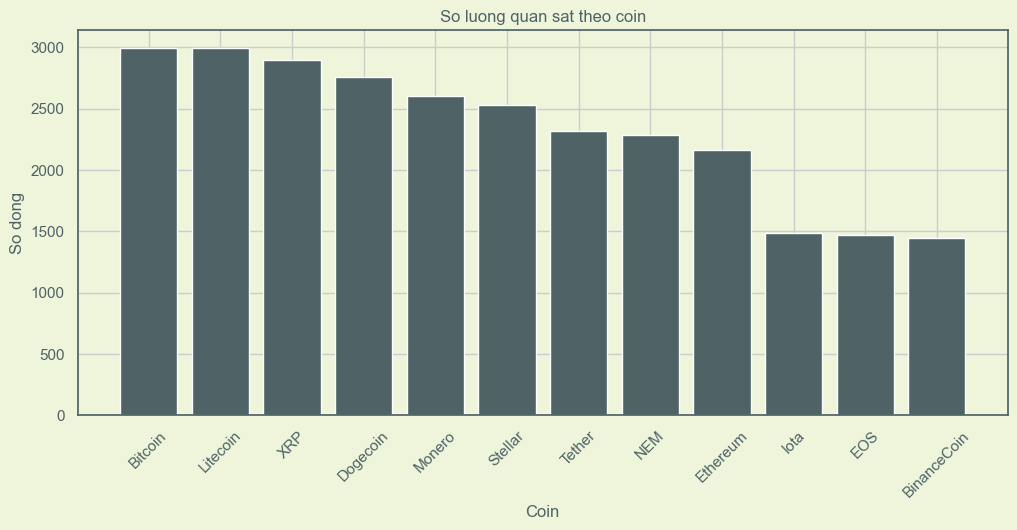

In [7]:
top_coins = coin_stats.head(12).reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_coins["coin"], top_coins["rows"], color=palette["stormcloud"])
ax.set_title("So luong quan sat theo coin")
ax.set_xlabel("Coin")
ax.set_ylabel("So dong")
ax.tick_params(axis="x", rotation=45)
plt.show()

In [8]:
price_pivot = df.pivot_table(index="date", columns="coin", values="close")
missing_ratio = price_pivot.isna().mean().sort_values(ascending=False).head(15)
missing_ratio.to_frame("missing_ratio")

,missing_ratio
coin,
Aave,0.908058
Uniswap,0.902374
Polkadot,0.893012
Solana,0.848880
Cosmos,0.717486
WrappedBitcoin,0.703109
CryptocomCoin,0.687396
USDCoin,0.664995
Cardano,0.540622


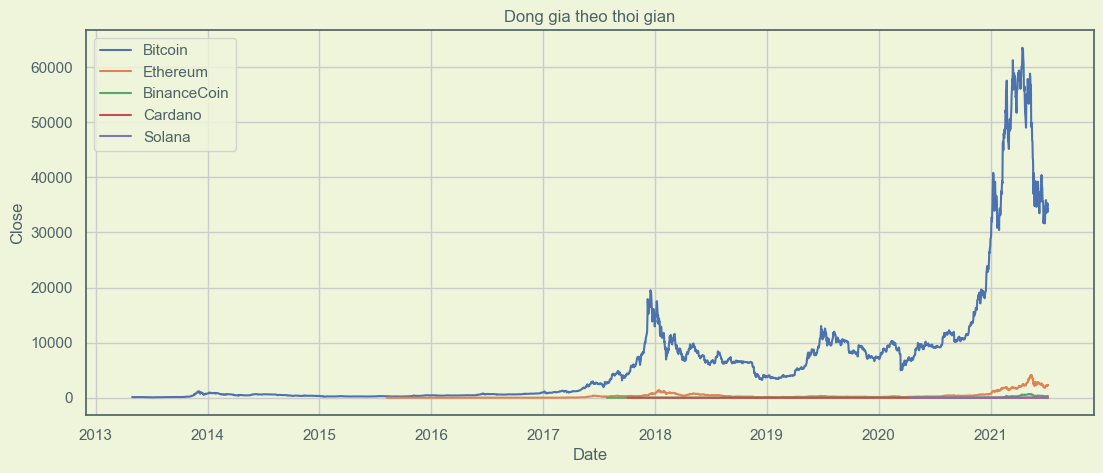

In [9]:
sample_coins = ["Bitcoin", "Ethereum", "BinanceCoin", "Cardano", "Solana"]
sub = df[df["coin"].isin(sample_coins)].copy()
fig, ax = plt.subplots(figsize=(13, 5))
for c in sample_coins:
    d = sub[sub["coin"] == c]
    ax.plot(d["date"], d["close"], linewidth=1.5, label=c)
ax.set_title("Dong gia theo thoi gian")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
plt.show()

In [10]:
returns = df.sort_values(["coin", "date"]).copy()
returns["return_1d"] = returns.groupby("coin")["close"].pct_change()
ret_stats = returns.groupby("coin")["return_1d"].agg(["mean", "std", "skew"]).dropna().sort_values("std", ascending=False)
ret_stats.head(15)

,mean,std,skew
coin,,,
Dogecoin,0.006622,0.113458,14.818003
Tron,0.006563,0.095264,4.411585
Solana,0.012795,0.094507,0.487637
Uniswap,0.008031,0.091299,0.990582
Polkadot,0.009018,0.087181,1.307372
NEM,0.005904,0.086892,4.619195
Aave,0.010243,0.086548,0.184880
Cardano,0.005876,0.083598,4.977004
XRP,0.004478,0.081566,5.548678


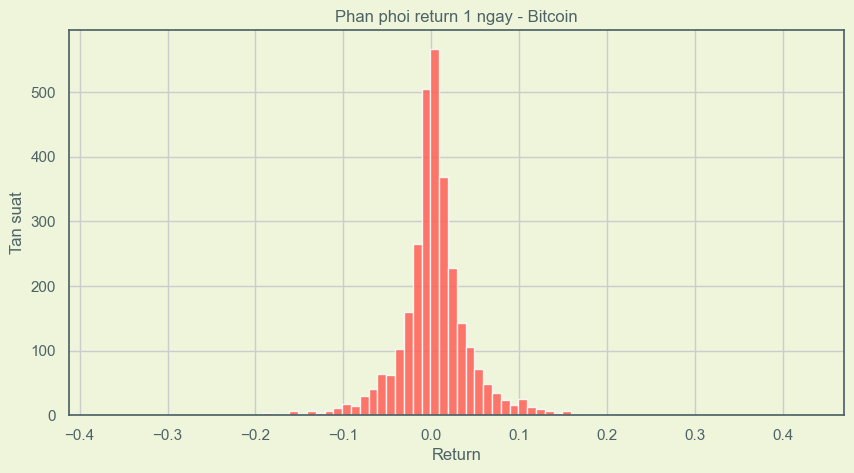

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
show_coin = "Bitcoin"
r = returns[returns["coin"] == show_coin]["return_1d"].dropna()
ax.hist(r, bins=80, color=palette["sunset"], alpha=0.85)
ax.set_title(f"Phan phoi return 1 ngay - {show_coin}")
ax.set_xlabel("Return")
ax.set_ylabel("Tan suat")
plt.show()

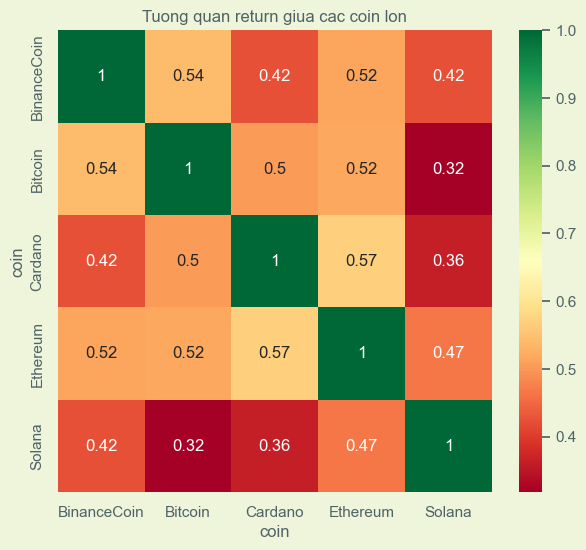

In [12]:
corr_base = returns[returns["coin"].isin(sample_coins)].pivot_table(index="date", columns="coin", values="return_1d")
corr = corr_base.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="RdYlGn", ax=ax)
ax.set_title("Tuong quan return giua cac coin lon")
plt.show()